# Lab 3: Why Classical Machine Learning

## Objective

- To understand Jaccard Similarity.
- To understand Cosine Similarity.
- To compare text documents using vectors.
- To understand the limitation of normal word matching.
- To understand why TF-IDF is used in classical machine learning.
- To understand how KNN can use cosine similarity.

---

## Theory
### 1. Jaccard Similarity

Jaccard Similarity:

JS = Intersection / Union

Paper 1: "Vision AI Vision"

Unique words:

{Vision, AI}

Size = 2

Paper 2: "NLP AI"

Unique words:

{NLP, AI}

Size = 2

Intersection = 1

Union = 3

JS(Paper 1, Paper 2) = 1 / 3 = 0.33

Limitation:

- Word repeat ignored.

---

### 2. Cosine Similarity

Cosine Similarity:

CS = A.B / |A||B|

A.B = a1b1 + a2b2 + c1c2

Vocabulary:

{Vision, AI, NLP}

Paper 1: "Vision AI Vision" → {2, 1, 0}

Paper 2: "NLP AI" → {0, 1, 1}

A.B = 2×0 + 1×1 + 0×1

A.B = 0 + 1 + 0 = 1

|A| = √(2² + 1² + 0²) = 2.236

|B| = √(0² + 1² + 1²) = 1.414

|A| × |B| = 2.236 × 1.414 = 3.162

Result:

CS = 1 / 3.162 = 0.316

---

### KNN Using Cosine Similarity

Documents can be converted into vectors.

Then cosine similarity is used to find the nearest documents.

KNN uses cosine similarity to classify the document based on nearby similar documents.

---

### Error

- All vectors or words are treated equally.
- We need something that has statistical weight.

---

### TF-IDF

TF-IDF = Term Frequency - Inverse Document Frequency

Terms:

1. Transformer for NLP
2. Transformer for CV
3. CNN for CV

Vocabulary:

{Transformer, NLP, CV, CNN}

IDF:

For common word:

log(3/3) = 0

Transformer:

log(3/2) = 0.40

NLP:

log(3/1) = 1.10

CV:

0.40

CNN:

1.10

So, common words get less weight and rare words get more weight.

---

---

## Discussion

In this lab, Jaccard Similarity and Cosine Similarity were used to compare text documents. Jaccard Similarity compared only unique words, so repeated words such as “Vision” were ignored. For the given example, the intersection was 1 and the union was 3, so the Jaccard Similarity was 0.33.

Cosine Similarity was then used by converting the documents into vectors. Paper 1 was represented as `[2, 1, 0]` and Paper 2 was represented as `[0, 1, 1]`. The dot product was 1, the magnitude of Paper 1 was 2.236, and the magnitude of Paper 2 was 1.414. Therefore, the cosine similarity was 0.316.

The lab also showed that simple vector representation has an error because all words are treated equally. This is not always correct because some words are more important than others. TF-IDF solves this problem by giving statistical weight to words. Common words get lower weight, while rare and important words get higher weight. These weighted vectors can then be used with KNN and cosine similarity for better document classification.

---

## Conclusion

This lab explained why classical machine learning needs numerical representation of text. Jaccard Similarity is simple but ignores repeated words. Cosine Similarity improves comparison by using vectors and word frequency. However, normal vectors treat all words equally, which creates errors. TF-IDF improves this by assigning statistical weight to words. Finally, KNN can use cosine similarity with these vectors to classify text documents more accurately.

In [3]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors 


paper_titles = [
    # Computer Vision Papers (1-10)
    ("ResNet-3D: Residual Grids for Spatial Volumetric Analysis", "CV", "CNNs", "Dr_Y_LeCun"),
    ("ViT-Scale: Scaling Vision Transformers for Dense Prediction", "CV", "Transformers", "Dr_A_Vaswani"),
    ("SimCLR-V3: Contrastive Frameworks for Self-Supervised Vision", "CV", "CL", "Dr_G_Hinton"),
    ("Masked Autoencoders Are Scalable Vision Visualizers", "CV", "Transformers", "Dr_Y_LeCun"),
    ("NeRF-Graph: Neural Radiance Fields on Graph Topologies", "CV", "GNNs", "Dr_J_Leskovec"),
    ("Real-Time Semantic Segmentation via Dilated Spatial Kernels", "CV", "CNNs", "Dr_Y_LeCun"),
    ("Cross-Modal Vector Alignment in Generative Vision Spaces", "CV", "CL", "Dr_G_Hinton"),
    ("Attention-Driven Object Detection in High-Resolution Imagery", "CV", "Transformers", "Dr_A_Vaswani"),
    ("Unsupervised Visual Representation via Contrastive Residuals", "CV", "CL", "Dr_G_Hinton"),
    ("Geometry-Aware Convolutions for 3D Point Cloud Processing", "CV", "CNNs", "Dr_J_Leskovec"),
    
    # NLP Papers (11-20)
    ("BERT-Large: Pre-training of Deep Bidirectional Transformers", "NLP", "Transformers", "Dr_A_Vaswani"),
    ("GPT-Next: Autoregressive Language Modeling at Scale", "NLP", "Transformers", "Dr_A_Vaswani"),
    ("Contrastive Sentence Embeddings via Semantic Invariance", "NLP", "CL", "Dr_Y_Bengio"),
    ("Long-Short Sequence Parsing via Linear Attention Windows", "NLP", "Transformers", "Dr_A_Vaswani"),
    ("Text-Graph Recurrent Transformers for Structured Document Analysis", "NLP", "GNNs", "Dr_J_Leskovec"),
    ("Exploring the Limits of Self-Supervised Machine Translation", "NLP", "CL", "Dr_Y_Bengio"),
    ("Dependency-Parsing Convolutions for Low-Resource Languages", "NLP", "CNNs", "Dr_Y_LeCun"),
    ("Token-Free Language Representations via Character-Level Processing", "NLP", "Transformers", "Dr_Y_Bengio"),
    ("Retrieval-Augmented Transformers for Dynamic Knowledge Graphs", "NLP", "Transformers", "Dr_J_Leskovec"),
    ("Evaluating Prompt Calibration Metrics in LLM Quantization", "NLP", "Transformers", "Dr_Y_Bengio"),

    # Graph AI Papers (21-30)
    ("GCN-V2: Scalable Graph Convolutional Networks via Node Sampling", "Graph_AI", "GNNs", "Dr_J_Leskovec"),
    ("Graph Attention Networks with Multi-Head Structural Alignment", "Graph_AI", "Transformers", "Dr_A_Vaswani"),
    ("Self-Supervised Graph Contrastive Learning via Subgraph Masking", "Graph_AI", "CL", "Dr_Y_Bengio"),
    ("Message-Passing Frameworks for Heterogeneous Molecular Topologies", "Graph_AI", "GNNs", "Dr_G_Hinton"),
    ("Graph Convolutions Meet Vision Transformers: A Unified Review", "Graph_AI", "Transformers", "Dr_Y_LeCun"),
    ("Temporal Graph Networks for Dynamic Relational Interaction Stream", "Graph_AI", "GNNs", "Dr_J_Leskovec"),
    ("Inductive Representation Learning on Large-Scale Social Webs", "Graph_AI", "GNNs", "Dr_J_Leskovec"),
    ("Contrastive Node Clustering via Graph Diffusion Wavelets", "Graph_AI", "CL", "Dr_G_Hinton"),
    ("Deep Generative Models for Graph Structure Deconvolution", "Graph_AI", "CNNs", "Dr_Y_LeCun"),
    ("Scalable Graph Neural Architecture Search via Gradient Descent", "Graph_AI", "GNNs", "Dr_Y_Bengio")
]

# Convert the raw nested sequence into a structured Pandas DataFrame
columns = ["Title", "Domain_Code", "Methodology_Code", "Primary_Author"]
df = pd.DataFrame(paper_titles, columns=columns)
df.insert(0, 'Paper_ID', range(1, len(df) + 1))

# Optionally save to disk to inspect structural data
df.to_csv('research_papers_network.csv', index=False)


# Combine descriptive features and text metadata fields into a singular text profile string
df['Features_Corpus'] = df['Title'] + " " + df['Domain_Code'] + " " + df['Methodology_Code'] + " " + df['Primary_Author']

# Lowercase everything to ensure string consistency and eliminate casing bias
df['Features_Corpus'] = df['Features_Corpus'].str.lower()


vectorizer = TfidfVectorizer(stop_words='english', token_pattern=r'(?u)\b\w+\b')

tfidf_matrix = vectorizer.fit_transform(df['Features_Corpus'])


knn_model = NearestNeighbors(n_neighbors=6, metric='cosine', algorithm='brute')
knn_model.fit(tfidf_matrix)

target_title = "Unsupervised Visual Representation via Contrastive Residuals"
query_idx = df[df['Title'] == target_title].index[0]

# Query the KNN tree to get spatial coordinate arrays for closest nodes
distances, indices = knn_model.kneighbors(tfidf_matrix[query_idx])

# Display machine learning recommendations
print(f"Target Input Paper: '{df.iloc[query_idx]['Title']}'")
print("=" * 95)

# Loop starting from index 1 (skipping 0 because index 0 is always the target paper itself)
for rank in range(1, len(distances[0])):
    match_idx = indices[0][rank]
    cosine_distance = distances[0][rank]
    
    # Mathematical transformation: Similarity = 1 - Distance
    similarity_score = 1 - cosine_distance
    
print(f"Recommendation #{rank:02d}: {df.iloc[match_idx]['Title']:<70} [Score: {similarity_score:.4f}]")

Target Input Paper: 'Unsupervised Visual Representation via Contrastive Residuals'
Recommendation #05: Self-Supervised Graph Contrastive Learning via Subgraph Masking        [Score: 0.1553]


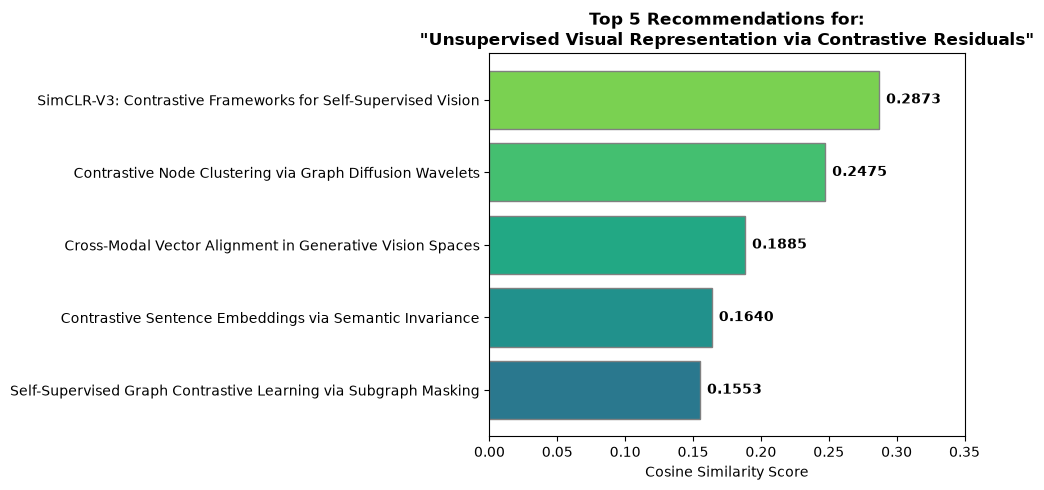

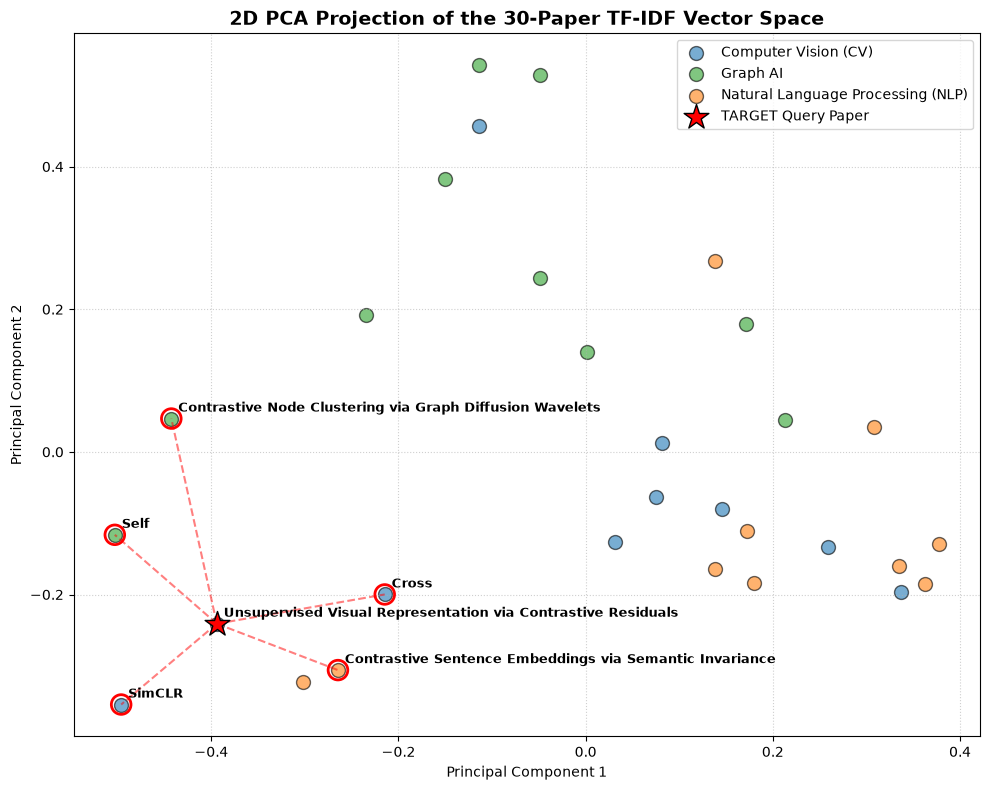

Visualizations successfully compiled and saved to disk.


In [4]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# ==============================================================================
# VISUALIZATION MODULE 1: HORIZONTAL BAR CHART OF TOP SIMILARITIES
# ==============================================================================
rec_titles = []
rec_scores = []
for rank in range(1, len(distances[0])):
    match_idx = indices[0][rank]
    sim_score = 1 - distances[0][rank]
    rec_titles.append(df.iloc[match_idx]['Title'])
    rec_scores.append(sim_score)

# Sort recommendations to guarantee sorted descending presentation
rec_data = sorted(zip(rec_titles, rec_scores), key=lambda x: x[1])
sorted_titles, sorted_scores = zip(*rec_data)

# Create Plot canvas using standard subplots to avoid truncation
fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.viridis(np.linspace(0.4, 0.8, len(sorted_scores)))
bars = ax.barh(sorted_titles, sorted_scores, color=colors, edgecolor='grey')

ax.set_xlabel('Cosine Similarity Score')
ax.set_title(f'Top 5 Recommendations for:\n"{target_title}"', fontsize=12, fontweight='bold')
ax.set_xlim(0, 0.35)

# Append raw score values cleanly onto the tips of the bars
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.005, bar.get_y() + bar.get_height()/2, f'{width:.4f}', 
            va='center', ha='left', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()
plt.close()


# ==============================================================================
# VISUALIZATION MODULE 2: 2D GEOMETRIC PCA PROJECTION 
# ==============================================================================
# Compress sparse matrix coordinates to a 2D dense layout plane
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(tfidf_matrix.toarray())
df['X'], df['Y'] = coords[:, 0], coords[:, 1]

fig, ax = plt.subplots(figsize=(10, 8))

# Distribute colors cleanly mapping across academic domain codes
domain_colors = {'CV': '#1f77b4', 'NLP': '#ff7f0e', 'Graph_AI': '#2ca02c'}
domain_labels = {'CV': 'Computer Vision (CV)', 'NLP': 'Natural Language Processing (NLP)', 'Graph_AI': 'Graph AI'}

for domain, group in df.groupby('Domain_Code'):
    ax.scatter(group['X'], group['Y'], label=domain_labels[domain], 
               color=domain_colors[domain], s=100, alpha=0.6, edgecolors='black')

# Anchor and highlight target paper index
target_x, target_y = df.iloc[query_idx]['X'], df.iloc[query_idx]['Y']
ax.scatter(target_x, target_y, color='red', marker='*', s=350, 
           label='TARGET Query Paper', edgecolors='black', zorder=5)

# Draw spatial connection lines to matching neighbors
neighbor_indices = indices[0][1:]
for idx in neighbor_indices:
    nx, ny = df.iloc[idx]['X'], df.iloc[idx]['Y']
    ax.scatter(nx, ny, facecolors='none', edgecolors='red', s=200, linewidths=2, zorder=4)
    ax.plot([target_x, nx], [target_y, ny], color='red', linestyle='--', alpha=0.5, zorder=3)

# Overlay short acronym annotations onto the vector nodes
for i, row in df.iterrows():
    if i == query_idx or i in neighbor_indices:
        short_name = row['Title'].split(':')[0].split('-')[0]
        ax.annotate(short_name, (row['X'], row['Y']), textcoords="offset points", 
                    xytext=(5,5), ha='left', fontsize=9, weight='bold')

ax.set_title('2D PCA Projection of the 30-Paper TF-IDF Vector Space', fontsize=14, fontweight='bold')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.legend(loc='best')
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
# plt.savefig('vector_space_projection.png', dpi=300)
plt.show()
plt.close()

print("Visualizations successfully compiled and saved to disk.")